# Sawaya Gate-Count Comparison

This notebook has two jobs:

1. Replot digitized Sawaya displacement-gate CNOT counts for standard binary, Gray, and unary encodings.
2. Use selected displacement CNOT counts to estimate full Hamiltonian entangling-gate costs as the number of sites grows.

The original exploratory notebook is `sawaya_ella.ipynb`. This copy keeps the same calculations but makes the order and assumptions easier to follow.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Digitized Sawaya Displacement Data

These arrays were digitized from the Sawaya displacement-gate CNOT-count plot using WebPlotDigitizer. Each row is `(bosonic cutoff d, CNOT count)`.

In [2]:
# -------------------------
# Sawaya gate counts for displacements in Gray
# -------------------------

sawaya_gray = np.array([
    [1.982905982905983, 0],
    [3.008547008547009, 4.01606425702812],
    [3.999999999999999, 3.614457831325325],
    [4.991452991452991, 18.07228915662651],
    [6.017094017094017, 18.07228915662651],
    [7.008547008547008, 18.07228915662651],
    [8.0, 17.670682730923716],
    [8.99145299145299, 57.42971887550203],
    [10.017094017094017, 57.42971887550203],
    [11.008547008547007, 57.02811244979921],
    [12.0, 57.42971887550203],
    [12.99145299145299, 57.42971887550203],
    [14.017094017094015, 57.02811244979921],
    [15.008547008547007, 57.02811244979921],
    [15.999999999999998, 57.42971887550203],
    [16.991452991452988, 152.20883534136544],
    [18.017094017094017, 152.20883534136544],
    [19.008547008547005, 152.20883534136544],
    [20.0, 152.20883534136544],
    [20.991452991452988, 152.20883534136544],
    [21.982905982905983, 152.20883534136544],
    [23.008547008547005, 151.80722891566268],
    [24.034188034188034, 151.80722891566268],
    [24.991452991452988, 152.20883534136544],
    [25.982905982905983, 151.80722891566268],
    [27.008547008547005, 152.20883534136544],
    [28.0, 152.20883534136544],
    [28.991452991452988, 151.80722891566268],
    [30.01709401709401, 152.20883534136544],
    [31.008547008547005, 152.20883534136544],
    [31.965811965811966, 152.20883534136544],
])

# -------------------------
# Sawaya gate counts for displacements in Standard Binary
# -------------------------

sawaya_sb = np.array([
    [1.982905982905983, -0.4016064257027665],
    [2.9743589743589745, 5.622489959839385],
    [3.965811965811966, 6.02409638554218],
    [4.957264957264957, 22.89156626506025],
    [6.017094017094017, 22.89156626506025],
    [7.008547008547008, 22.89156626506025],
    [8.0, 22.489959839357454],
    [8.99145299145299, 63.85542168674698],
    [10.017094017094017, 63.453815261044184],
    [11.008547008547007, 63.453815261044184],
    [12.0, 63.453815261044184],
    [12.99145299145299, 63.453815261044184],
    [14.017094017094015, 63.453815261044184],
    [15.008547008547007, 63.453815261044184],
    [16.034188034188034, 63.453815261044184],
    [16.991452991452988, 158.63453815261045],
    [18.017094017094017, 158.63453815261045],
    [19.04273504273504, 158.63453815261045],
    [20.0, 158.63453815261045],
    [20.991452991452988, 158.63453815261045],
    [21.982905982905983, 158.23293172690762],
    [23.04273504273504, 158.23293172690762],
    [24.0, 158.23293172690762],
    [25.025641025641022, 158.63453815261045],
    [26.017094017094017, 158.63453815261045],
    [27.008547008547005, 158.63453815261045],
    [28.0, 158.23293172690762],
    [28.957264957264954, 158.63453815261045],
    [29.982905982905976, 158.23293172690762],
    [31.008547008547005, 158.63453815261045],
    [31.965811965811966, 158.63453815261045],
])

# -------------------------
# Sawaya gate counts for displacements in Unary
# -------------------------

sawaya_unary = np.array([
    [2.017094017094017, 3.614457831325325],
    [3.008547008547009, 8.433734939759034],
    [3.999999999999999, 11.646586345381564],
    [5.0256410256410255, 16.06425702811248],
    [6.051282051282051, 19.678714859437775],
    [7.008547008547008, 24.09638554216872],
    [8.034188034188034, 27.710843373493987],
    [8.99145299145299, 32.12851405622493],
    [10.017094017094017, 35.742971887550226],
    [11.008547008547007, 39.35742971887552],
    [12.0, 43.77510040160644],
    [12.99145299145299, 47.79116465863456],
    [14.017094017094015, 51.40562248995985],
    [15.008547008547007, 55.421686746987945],
    [15.999999999999998, 59.83935742971889],
    [16.991452991452988, 63.85542168674698],
    [18.05128205128205, 67.8714859437751],
    [19.008547008547005, 71.4859437751004],
    [20.0, 75.50200803212851],
    [20.991452991452988, 79.51807228915666],
    [22.017094017094017, 83.53413654618475],
    [23.008547008547005, 87.55020080321285],
    [24.0, 91.56626506024097],
    [24.991452991452988, 95.98393574297188],
    [25.982905982905983, 99.59839357429718],
    [27.008547008547005, 104.01606425702812],
    [28.0, 107.63052208835342],
    [28.991452991452988, 112.04819277108436],
    [29.982905982905976, 115.66265060240966],
    [31.008547008547005, 120.08032128514057],
    [31.999999999999993, 123.69477911646587],
])

## 3. Replot Sawaya Displacement Counts

This recreates the displacement-gate count curves for the three encodings.

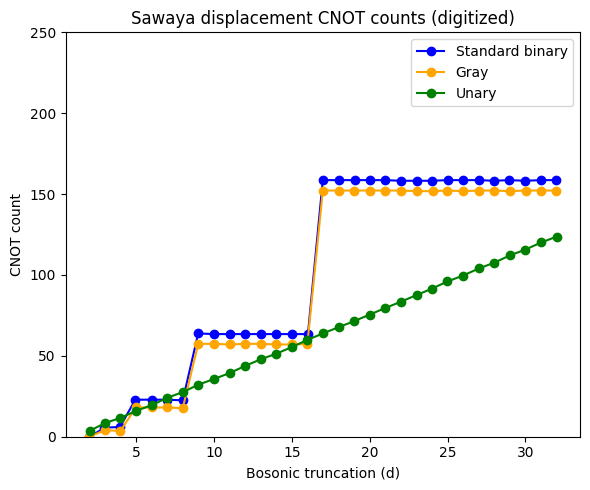

In [3]:
plt.figure(figsize=(6, 5))

plt.plot(
    sawaya_sb[:, 0],
    sawaya_sb[:, 1],
    color="blue",
    marker="o",
    label="Standard binary",
)

plt.plot(
    sawaya_gray[:, 0],
    sawaya_gray[:, 1],
    marker="o",
    color="orange",
    label="Gray",
)

plt.plot(
    sawaya_unary[:, 0],
    sawaya_unary[:, 1],
    marker="o",
    color="green",
    label="Unary",
)

plt.xlabel("Bosonic truncation (d)")
plt.ylabel("CNOT count")
plt.ylim(0, 250)
plt.title("Sawaya displacement CNOT counts (digitized)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Hamiltonian Estimate Parameters

These are the parameters used in the later full-Hamiltonian gate-count estimate (classical max out in the Cao / Kessing paper)

In [4]:
N = np.arange(2, 10)  # number of sites, also called L

N_max = 128
J = 100
g = 60
omega = 180
T = 4.5
epsilon = 0.1

tilt = 1
hbar = 1

## 5. Gate-Count Helper Functions

`alpha(...)` controls the estimated number of Hamiltonian-level Trotter steps. The all-qubit estimate assumes two displacement operations plus four controlled-phase-like terms per site. The qubit-boson estimate is a simple lower-cost baseline.

In [11]:
def alpha(N, N_max, J, g, tilt, hbar, omega):
    term1 = 2 * np.floor(N / 2) * abs(J)**2
    term2 = (4 * (N - 1) * abs(J * g) * np.sqrt(N_max))
    floor_term = np.floor((N - 1) / 2)
    term3 = (abs(J * tilt) * (4 * floor_term**2 + 2 * floor_term + (N - 1)))
    term4 = (2 * N * abs(hbar * omega * g) * np.sqrt(N_max))
    return term1 + term2 + term3 + term4

def trotter_steps(N, N_max=N_max, J=J, g=g, delta_eps=1, hbar=1, omega=omega, T=T, epsilon=epsilon):
    return alpha(N, N_max, J, g, delta_eps, hbar, omega) * T**2 / (2 * epsilon) # The 2 is needed for the small parameters


def all_qubit_hamiltonian_gate_count(N, cnot_D, N_max=N_max):
    return N * ((2 * cnot_D) + (4 * np.log2(N_max))) # Needs checking (i.e., currently wrong)


def qubit_boson_hamiltonian_gate_count(N):
    return N * (2 + 2) 


def plot_hamiltonian_estimate(title, displacement_cnot_counts):
    colors = {
        "Standard binary": "blue",
        "Gray": "orange",
        "Unary": "green",
    }

    plt.figure(figsize=(7, 5))

    for label, cnot_D in displacement_cnot_counts.items():
        plt.plot(
            N,
            all_qubit_hamiltonian_gate_count(N, cnot_D) * trotter_steps(N),
            marker="o",
            color=colors[label],
            label=f"{label}",
        )

    plt.plot(
        N,
        qubit_boson_hamiltonian_gate_count(N) * trotter_steps(N),
        marker="o",
        color="red",
        label="Qubit-boson baseline",
    )

    plt.yscale("log")
    plt.xlabel("Number of sites (L)")
    plt.ylabel("Entangling gates")
    plt.title(title)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

## 6. Displacement CNOT Counts Used Below

These are the per-displacement CNOT counts that feed into the Hamiltonian estimate. The Sawaya values are approximate values read from the digitized curves near `d = 32`. The Qiskit values are the counts used in the original notebook.

In [16]:
qiskit_1_step_displacement_counts = {
    "Standard binary": 2175,
    "Gray": 1674,
    "Unary": 508,
}

qiskit_10_step_displacement_counts = {
    "Standard binary": 21741,
    "Gray": 16740,
    "Unary": 5080,
}

## 7. Hamiltonian Estimate Using Qiskit Displacement Counts (1 Trotter steps)

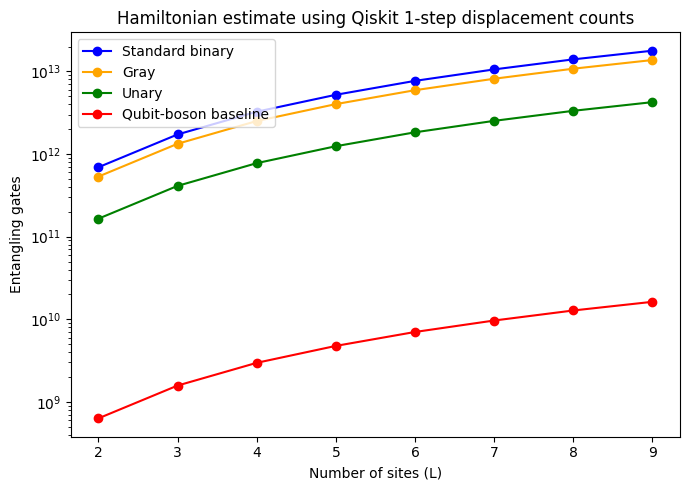

In [17]:
plot_hamiltonian_estimate(
    "Hamiltonian estimate using Qiskit 1-step displacement counts",
    qiskit_1_step_displacement_counts,
)

## 8. Hamiltonian Estimate Using Qiskit Displacement Counts (10 Trotter steps)

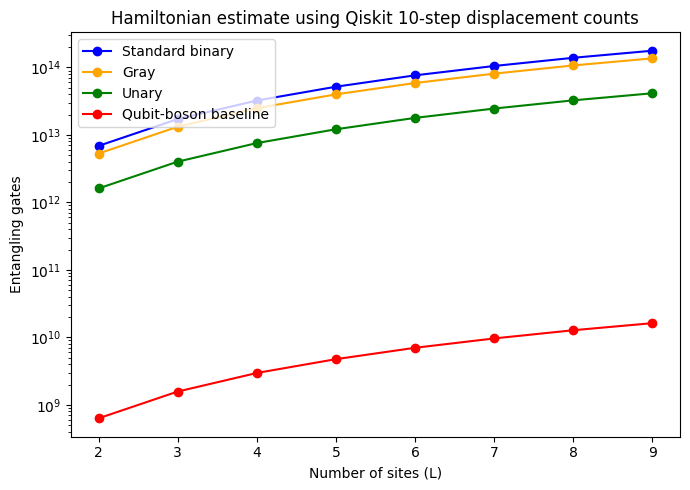

In [18]:
plot_hamiltonian_estimate(
    "Hamiltonian estimate using Qiskit 10-step displacement counts",
    qiskit_10_step_displacement_counts,
)